In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
import matplotlib.pyplot as plt
import numpy as np
BASE_PATH = "/content/drive/MyDrive/4-2/Deep Learning/Assignments/Assignment 5/results/"
def load_and_preprocess_data():
    # Load CIFAR-10 dataset
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

    # Normalize pixel values to [0, 1]
    x_train, x_test = x_train / 255.0, x_test / 255.0

    # Use a subset for faster training in Colab if needed
    # x_train, y_train = x_train[:20000], y_train[:20000]

    return x_train, y_train, x_test, y_test

def plot_results(history, title, filename):
    plt.figure(figsize=(12, 4))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    save_path = BASE_PATH + filename
    plt.savefig(save_path)
    print(f"Plot saved to: {save_path}")
    plt.show()

x_train, y_train, x_test, y_test = load_and_preprocess_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Training Underfitting Model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.3761 - loss: 1.7856 - val_accuracy: 0.4161 - val_loss: 1.6440
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4372 - loss: 1.6121 - val_accuracy: 0.4371 - val_loss: 1.5942
Epoch 3/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4554 - loss: 1.5547 - val_accuracy: 0.4448 - val_loss: 1.5639
Plot saved to: /content/drive/MyDrive/4-2/Deep Learning/Assignments/Assignment 5/results/underfit_plot.png


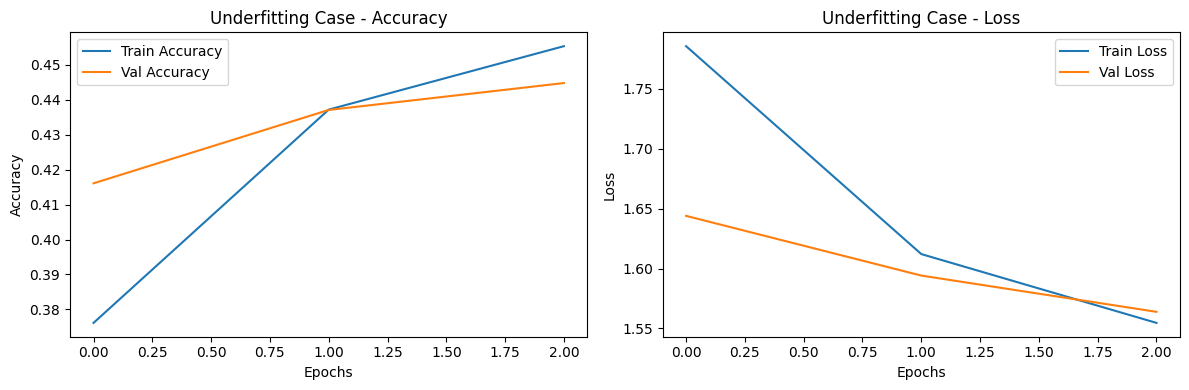


Training Overfitting Model...
Epoch 1/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 30s 56ms/step - accuracy: 0.4776 - loss: 1.4608 - val_accuracy: 0.5768 - val_loss: 1.1878
Epoch 2/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - accuracy: 0.6744 - loss: 0.9304 - val_accuracy: 0.6844 - val_loss: 0.8980
Epoch 3/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.7603 - loss: 0.6867 - val_accuracy: 0.7348 - val_loss: 0.7911
Epoch 4/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.8349 - loss: 0.4746 - val_accuracy: 0.7208 - val_loss: 0.8625
Epoch 5/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.9102 - loss: 0.2612 - val_accuracy: 0.7210 - val_loss: 1.0104
Epoch 6/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 17s 43ms/step - accuracy: 0.9611 - loss: 0.1170 - val_accuracy: 0.7250 - val_loss: 1.2196
Epoch 7/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 17s 43ms/step - accuracy: 0.9753 - loss: 0.0742 - val_accuracy: 0.7023 - val_loss: 1.6078
Epoch 8/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 17s 43ms/step - acc

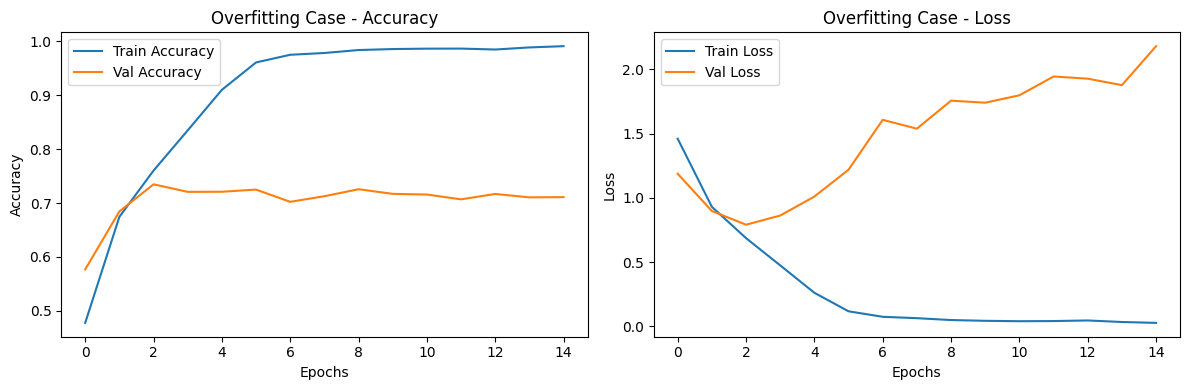

In [2]:
def build_underfit_model():
    # Extremely shallow, very few filters
    model = models.Sequential([
        layers.Conv2D(4, (3, 3), activation='relu', input_shape=(32, 32, 3)),
        layers.Flatten(),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def build_overfit_model():
    # Deep, many parameters, no regularization or dropout
    model = models.Sequential([
        layers.Conv2D(128, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Train Underfitting (Few epochs)
print("Training Underfitting Model...")
underfit_model = build_underfit_model()
h_underfit = underfit_model.fit(x_train, y_train, epochs=3, validation_data=(x_test, y_test), batch_size=128)
plot_results(h_underfit, "Underfitting Case", "underfit_plot.png")

# Train Overfitting (More epochs to see divergence)
print("\nTraining Overfitting Model...")
overfit_model = build_overfit_model()
h_overfit = overfit_model.fit(x_train, y_train, epochs=15, validation_data=(x_test, y_test), batch_size=128)
plot_results(h_overfit, "Overfitting Case", "overfit_plot.png")


Training Regularized (L2) Model...
Epoch 1/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 27s 61ms/step - accuracy: 0.4489 - loss: 1.8233 - val_accuracy: 0.5579 - val_loss: 1.4490
Epoch 2/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 34s 49ms/step - accuracy: 0.5951 - loss: 1.3705 - val_accuracy: 0.6135 - val_loss: 1.3337
Epoch 3/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step - accuracy: 0.6550 - loss: 1.2186 - val_accuracy: 0.6659 - val_loss: 1.1749
Epoch 4/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 48ms/step - accuracy: 0.6877 - loss: 1.1332 - val_accuracy: 0.6752 - val_loss: 1.1790
Epoch 5/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - accuracy: 0.7067 - loss: 1.0825 - val_accuracy: 0.6949 - val_loss: 1.1108
Epoch 6/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 47ms/step - accuracy: 0.7217 - loss: 1.0440 - val_accuracy: 0.7019 - val_loss: 1.1090
Epoch 7/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 48ms/step - accuracy: 0.7374 - loss: 1.0133 - val_accuracy: 0.7022 - val_loss: 1.1282
Epoch 8/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step 

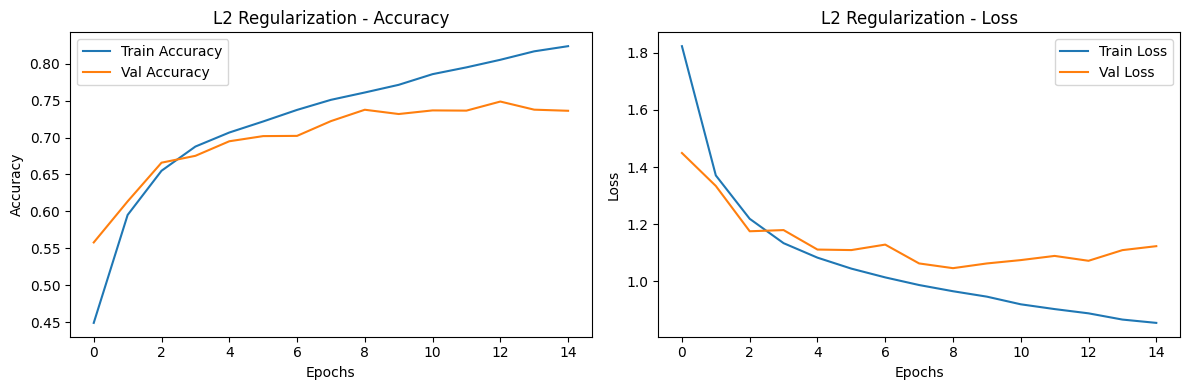

In [3]:
def build_regularized_model(l2_val=0.001):
    model = models.Sequential([
        layers.Conv2D(128, (3, 3), activation='relu', padding='same',
                      kernel_regularizer=regularizers.l2(l2_val), input_shape=(32, 32, 3)),
        layers.Conv2D(128, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(l2_val)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(256, (3, 3), activation='relu', padding='same', kernel_regularizer=regularizers.l2(l2_val)),
        layers.Flatten(),
        layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(l2_val)),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

print("\nTraining Regularized (L2) Model...")
reg_model = build_regularized_model()
h_reg = reg_model.fit(x_train, y_train, epochs=15, validation_data=(x_test, y_test), batch_size=128)
plot_results(h_reg, "L2 Regularization", "reg_plot.png")


Training Dropout Model...
Epoch 1/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 31s 67ms/step - accuracy: 0.3647 - loss: 1.7466 - val_accuracy: 0.5147 - val_loss: 1.3532
Epoch 2/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 48ms/step - accuracy: 0.5305 - loss: 1.3176 - val_accuracy: 0.6103 - val_loss: 1.1033
Epoch 3/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 48ms/step - accuracy: 0.6035 - loss: 1.1188 - val_accuracy: 0.6617 - val_loss: 0.9747
Epoch 4/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 18s 45ms/step - accuracy: 0.6537 - loss: 0.9848 - val_accuracy: 0.6793 - val_loss: 0.9143
Epoch 5/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 44ms/step - accuracy: 0.6815 - loss: 0.8909 - val_accuracy: 0.6907 - val_loss: 0.8840
Epoch 6/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 48ms/step - accuracy: 0.7125 - loss: 0.8130 - val_accuracy: 0.7134 - val_loss: 0.8194
Epoch 7/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - accuracy: 0.7418 - loss: 0.7341 - val_accuracy: 0.7234 - val_loss: 0.8087
Epoch 8/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 18s 46ms/step - accurac

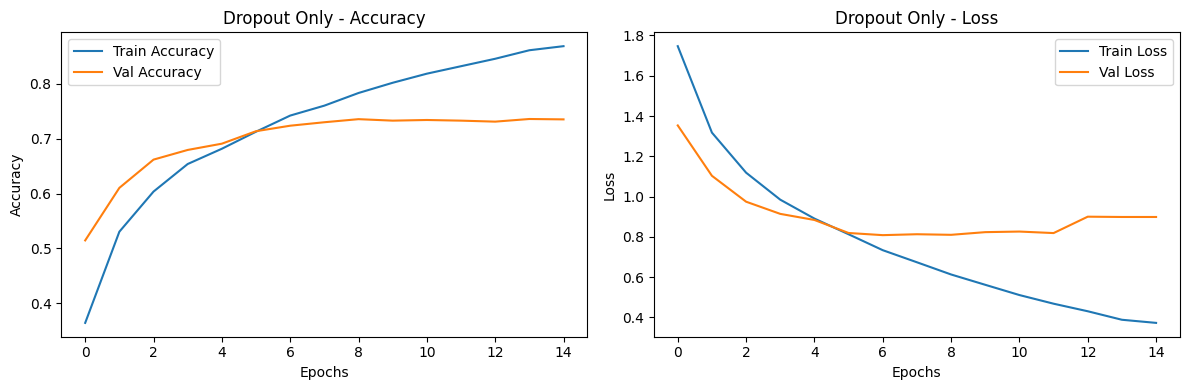

In [4]:
def build_dropout_model(rate=0.5):
    model = models.Sequential([
        layers.Conv2D(128, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        layers.Dropout(rate),
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(rate),
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(rate),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

print("\nTraining Dropout Model...")
drop_model = build_dropout_model()
h_drop = drop_model.fit(x_train, y_train, epochs=15, validation_data=(x_test, y_test), batch_size=128)
plot_results(h_drop, "Dropout Only", "dropout_plot.png")


Training Combined (L2 + Dropout) Model...
Epoch 1/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 33s 67ms/step - accuracy: 0.3582 - loss: 2.0609 - val_accuracy: 0.4845 - val_loss: 1.5957
Epoch 2/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 53ms/step - accuracy: 0.4950 - loss: 1.5494 - val_accuracy: 0.5569 - val_loss: 1.3995
Epoch 3/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step - accuracy: 0.5410 - loss: 1.4240 - val_accuracy: 0.5907 - val_loss: 1.2952
Epoch 4/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - accuracy: 0.5717 - loss: 1.3408 - val_accuracy: 0.6218 - val_loss: 1.2412
Epoch 5/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 50ms/step - accuracy: 0.5975 - loss: 1.2803 - val_accuracy: 0.6205 - val_loss: 1.2141
Epoch 6/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step - accuracy: 0.6141 - loss: 1.2345 - val_accuracy: 0.6541 - val_loss: 1.1378
Epoch 7/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 50ms/step - accuracy: 0.6319 - loss: 1.1994 - val_accuracy: 0.6726 - val_loss: 1.1041
Epoch 8/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 49m

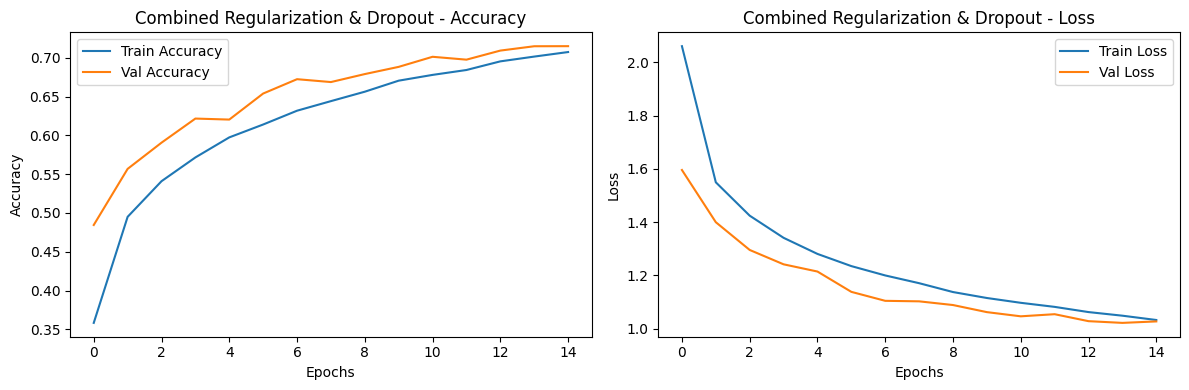

In [5]:
def build_combined_model(l2_val=0.0005, drop_rate=0.4):
    model = models.Sequential([
        layers.Conv2D(128, (3, 3), activation='relu', padding='same',
                      kernel_regularizer=regularizers.l2(l2_val), input_shape=(32, 32, 3)),
        layers.Dropout(drop_rate),
        layers.Conv2D(128, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(l2_val)),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(drop_rate),
        layers.Conv2D(256, (3, 3), activation='relu', padding='same', kernel_regularizer=regularizers.l2(l2_val)),
        layers.Flatten(),
        layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(l2_val)),
        layers.Dropout(drop_rate),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

print("\nTraining Combined (L2 + Dropout) Model...")
comb_model = build_combined_model()
h_comb = comb_model.fit(x_train, y_train, epochs=15, validation_data=(x_test, y_test), batch_size=128)
plot_results(h_comb, "Combined Regularization & Dropout", "combined_plot.png")

def main():
    labels = ['Underfit', 'Overfit', 'L2 Reg', 'Dropout', 'Combined']
    val_accs = [
        max(h_underfit.history['val_accuracy']),
        max(h_overfit.history['val_accuracy']),
        max(h_reg.history['val_accuracy']),
        max(h_drop.history['val_accuracy']),
        max(h_comb.history['val_accuracy'])
    ]

    plt.figure(figsize=(10, 6))
    plt.bar(labels, val_accs, color=['red', 'blue', 'green', 'orange', 'purple'])
    plt.ylabel('Max Validation Accuracy')
    plt.title('Performance Comparison across Scenarios')
    save_path = BASE_PATH + "final_performance_comparison.png"
    plt.savefig(save_path)
    print(f"Comparison plot saved to: {save_path}")
    plt.show()



Comparison plot saved to: /content/drive/MyDrive/4-2/Deep Learning/Assignments/Assignment 5/results/final_performance_comparison.png


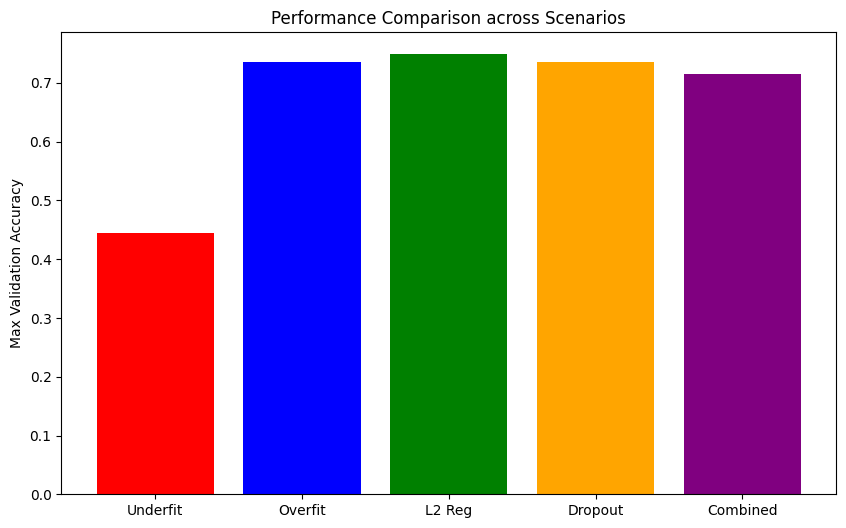

In [6]:
main()